# Khai báo thư viện và Đọc ảnh gốc

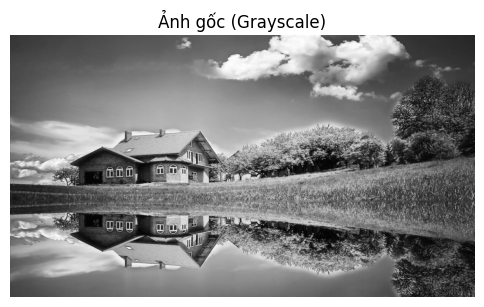

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Đọc ảnh gốc
img_bgr = cv2.imread('lab02.jpg')
# Chuyển sang Gray để làm bài tập và RGB để hiển thị đúng màu trên Notebook
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Hàm hỗ trợ hiển thị ảnh nhanh trong Notebook
def plt_show(img, title="Image", gray=False):
    plt.figure(figsize=(6,6))
    if gray:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

plt_show(img_gray, "Ảnh gốc (Grayscale)", gray=True)

# Toán tử điểm ảnh (Độ sáng & Tương phản)

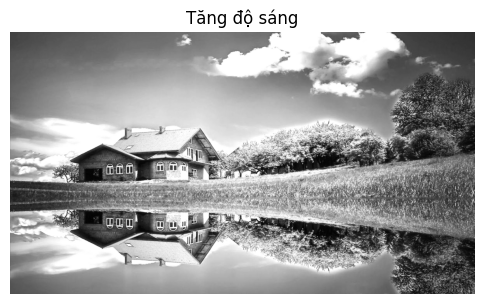

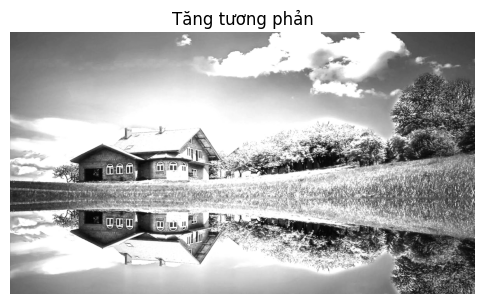

In [3]:
# 1. Thay đổi độ sáng (Cộng/Trừ)
bright = cv2.add(img_gray, 50)  # Tăng 50 đơn vị
dark = cv2.subtract(img_gray, 50) # Giảm 50 đơn vị

# 2. Thay đổi độ tương phản (Nhân hằng số)
high_contrast = cv2.multiply(img_gray, 1.5)

plt_show(bright, "Tăng độ sáng", gray=True)
plt_show(high_contrast, "Tăng tương phản", gray=True)

# Toán tử điểm ảnh (Âm bản & Cắt ngưỡng)

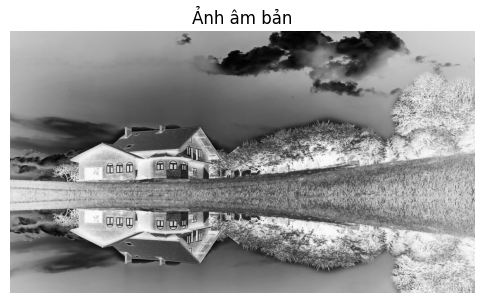

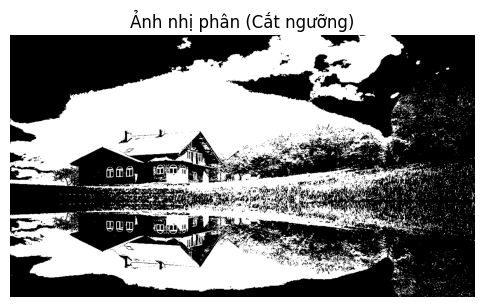

In [4]:
# 3. Biến đổi âm bản
negative = 255 - img_gray

# 4. Cắt ngưỡng (Binary Thresholding)
# Nếu pixel > 127 thì thành 255 (trắng), ngược lại là 0 (đen)
ret, thresh = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY)

plt_show(negative, "Ảnh âm bản", gray=True)
plt_show(thresh, "Ảnh nhị phân (Cắt ngưỡng)", gray=True)

# Lọc tuyến tính (Làm mờ & Làm sắc nét)

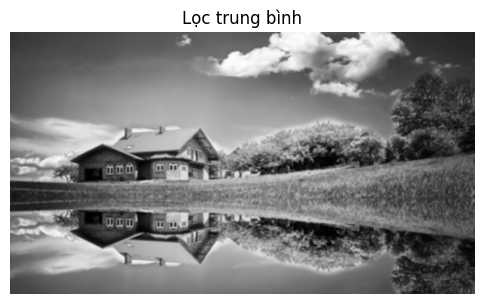

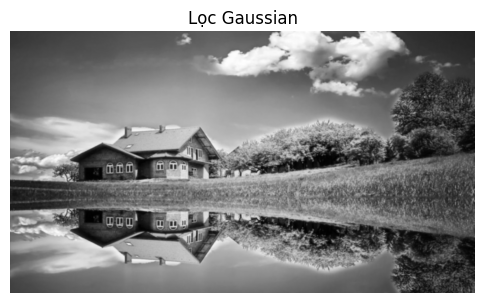

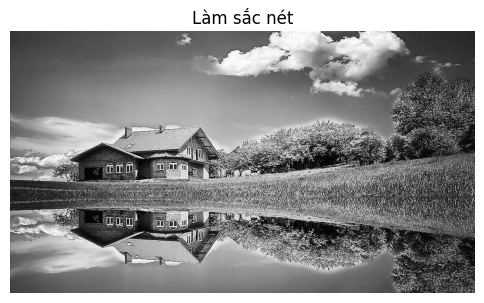

In [5]:
# 1. Lọc trung bình (Box Blur)
blur_avg = cv2.blur(img_gray, (5, 5))

# 2. Lọc Gaussian (Mờ mịn hơn)
blur_gau = cv2.GaussianBlur(img_gray, (5, 5), 0)

# 3. Làm sắc nét (Sharpening)
kernel_sharpen = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]])
sharpened = cv2.filter2D(img_gray, -1, kernel_sharpen)

plt_show(blur_avg, "Lọc trung bình", gray=True)
plt_show(blur_gau, "Lọc Gaussian", gray=True)
plt_show(sharpened, "Làm sắc nét", gray=True)

# Nâng cao (Phát hiện cạnh Sobel & Prewitt)

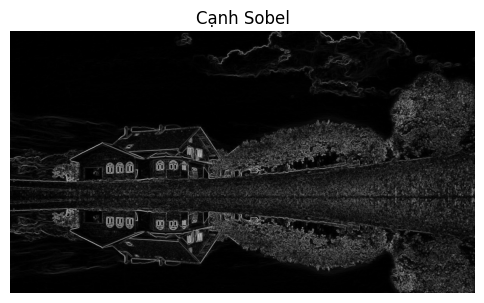

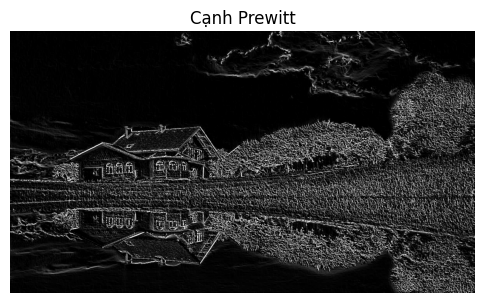

In [6]:
# 1. Phát hiện cạnh Sobel
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

# 1b. Phát hiện cạnh Prewitt (Dùng kernel tự định nghĩa)
kernelx = np.array([[1,1,1],[0,0,0],[-1,-1,-1]])
kernely = np.array([[-1,0,1],[-1,0,1],[-1,0,1]])
prewitt_x = cv2.filter2D(img_gray, -1, kernelx)
prewitt_y = cv2.filter2D(img_gray, -1, kernely)

plt_show(sobel_combined, "Cạnh Sobel", gray=True)
plt_show(prewitt_x + prewitt_y, "Cạnh Prewitt", gray=True)

# Lọc phi tuyến tính (Median & Bilateral)

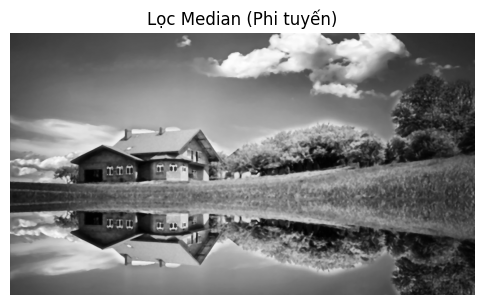

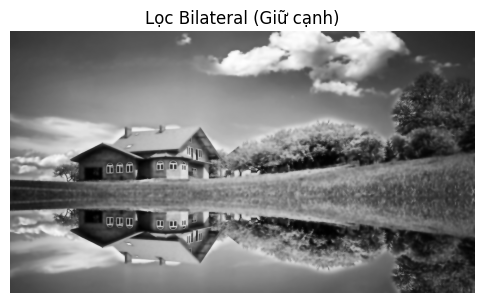

In [7]:
# 4. Lọc Median (Khử nhiễu hạt tiêu rất tốt)
median = cv2.medianBlur(img_gray, 5)

# 4b. Lọc Bilateral (Làm mịn da nhưng giữ cạnh)
bilateral = cv2.bilateralFilter(img_gray, 9, 75, 75)

plt_show(median, "Lọc Median (Phi tuyến)", gray=True)
plt_show(bilateral, "Lọc Bilateral (Giữ cạnh)", gray=True)